# 03 — Sign-selective causal repair

Necessity-test для signed path components. На patched-входе Detect head выбранные координаты возвращаются к clean-значениям. Основной endpoint — rescue того же target после NMS; fixed-cell logit, confidence и IoU анализируются отдельно.

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

cwd = Path.cwd().resolve()
REPO_ROOT = next((p for p in [cwd, *cwd.parents] if (p / 'new_experiments').exists()), None)
if REPO_ROOT is None: raise RuntimeError('Run from inside PatchSuccessResearch')
if str(REPO_ROOT) not in sys.path: sys.path.insert(0, str(REPO_ROOT))

from CandidateRoutingAndAttackPath import load_experiment
from CandidateRoutingAndAttackPath.balanced_target_path import GROUP_ORDER
from CandidateRoutingAndAttackPath.causal_repair import CausalRepairConfig, load_causal_repair, run_causal_repair
pd.set_option('display.max_columns', 100); plt.rcParams['figure.dpi'] = 110
print('repo:', REPO_ROOT)

repo: /Users/ashentide/PycharmProjects/PatchSuccessResearch


In [2]:
OUTPUT_ROOT = REPO_ROOT / 'CandidateRoutingAndAttackPath' / 'outputs'
TRACE_DB = OUTPUT_ROOT / 'candidate_trace_b3c25981c3ad62d5' / 'candidate_tracing.sqlite'
ATTACK_PATH_DB = OUTPUT_ROOT / 'attack_path_0060cc9878ecdb6e' / 'attack_path.sqlite'
MANIFEST_CSV = OUTPUT_ROOT / 'target_instance_all_metrics' / 'balanced_target_selection_5e479438583b28b0' / 'balanced_target_manifest.csv'
RUN_CAUSAL_REPAIR = True
FORCE_CAUSAL_REPAIR = False
MATCH_IOU, DETECTION_CONF = 0.50, 0.25

for path in [TRACE_DB, ATTACK_PATH_DB, MANIFEST_CSV]:
    if not path.exists(): raise FileNotFoundError(path)
exp, _ = load_experiment(repo_root=REPO_ROOT, prefer_dataset='COCO_people', prefer_device='mps', require_device=False)
repair_config = CausalRepairConfig(
    output_dir=str(OUTPUT_ROOT), max_output_gb=8.0, max_examples=None,
    k_values=(10, 50, 100, 250, 500, 1000), random_repeats=3,
    forward_batch_size=8, detection_conf=DETECTION_CONF, match_iou=MATCH_IOU,
    seed=53, progress=True,
)
display(pd.Series({name: getattr(repair_config, name) for name in repair_config.__slots__}).to_frame('value'))

,value
output_dir,/Users/ashentide/PycharmProjects/PatchSuccessR...
max_output_gb,8.0
max_examples,None
k_values,"(10, 50, 100, 250, 500, 1000)"
random_repeats,3
forward_batch_size,8
detection_conf,0.25
match_iou,0.5
nms_conf,0.01
nms_iou,0.7


## Дизайн

- `top_negative`: основной sign-selective repair;
- `top_positive`: контроль знака;
- `top_abs`: unsigned attribution;
- `delta_magnitude`: крупнейшие activation changes без attribution;
- `random_delta_matched`: случайные координаты с похожей magnitude, 3 повтора;
- clean target level и полный clean head: upper bounds.

Primary strategy comparisons делаются при `k <= 250`, где actual intervention budget одинаков. `k=500/1000` — только saturation doses.

In [3]:
if RUN_CAUSAL_REPAIR:
    repair_result = run_causal_repair(
        exp, ATTACK_PATH_DB, TRACE_DB, MANIFEST_CSV, repair_config, force=FORCE_CAUSAL_REPAIR,
    )
    print('DB:', repair_result.db_path)
    print('summary:', repair_result.group_summary_path)
    print('digest:', repair_result.digest_path)
else:
    raise RuntimeError('Set RUN_CAUSAL_REPAIR=True or assign an existing repair_result')

causal repair:   0%|          | 0/400 [00:00<?, ?img/s]

WARNING ⚠️ NMS time limit 2.400s exceeded
DB: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/causal_repair_45b3c22295b10aba/causal_repair.sqlite
summary: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/causal_repair_45b3c22295b10aba/repair_group_summary.csv
digest: /Users/ashentide/PycharmProjects/PatchSuccessResearch/CandidateRoutingAndAttackPath/outputs/causal_repair_45b3c22295b10aba/analysis_digest.md


In [4]:
repair = load_causal_repair(repair_result)
display(pd.read_json(repair_result.summary_path, typ='series').to_frame('value'))
repair_unit = (repair.groupby(
    ['example_id','analysis_group','match_set','strategy','k_requested'], as_index=False
).agg(
    actual_k=('actual_k','mean'), target_logit_gain=('target_logit_gain','mean'),
    fixed_target_logit=('fixed_target_logit','mean'), target_match_conf=('target_match_conf','mean'),
    target_max_iou=('target_max_iou','mean'), target_detected=('target_detected','mean'),
    restored_delta_l1=('restored_delta_l1','mean'),
))
baseline = repair_unit.query("strategy == 'patched'").copy()
baseline['expected_detected'] = (~baseline.analysis_group.str.startswith('hidden')).astype(int)
display(pd.crosstab(baseline.expected_detected, baseline.target_detected, rownames=['expected'], colnames=['recomputed']))
display(pd.read_csv(repair_result.group_summary_path).head(100))

,value
status,complete
n_examples,400
expected_examples,400
n_rows,18000
expected_rows,18000
error_rows,0
group_counts,"{'hidden_low_conf_match': 100, 'hidden_no_iou_..."
strategies,"[delta_magnitude, oracle_full_head, oracle_tar..."
k_values,"[10, 50, 100, 250, 500, 1000]"
database,/Users/ashentide/PycharmProjects/PatchSuccessR...


recomputed,0.0,1.0
expected,,
0,193,7
1,0,200


,analysis_group,strategy,k_requested,n,n_rows,mean_actual_k,rescue_rate,mean_target_logit,mean_logit_gain,mean_target_conf,mean_conf_gain,mean_target_iou,mean_iou_gain,mean_fixed_box_iou,mean_restored_delta_l1
0,hidden_low_conf_match,delta_magnitude,10,100,100,10.00,0.01,-4.115348,0.052864,0.119349,0.006596,0.712885,0.000223,0.734498,77.071092
1,hidden_low_conf_match,delta_magnitude,50,100,100,50.00,0.05,-4.012363,0.155848,0.127608,0.014855,0.737424,0.024763,0.769258,302.984668
2,hidden_low_conf_match,delta_magnitude,100,100,100,100.00,0.10,-3.827814,0.340398,0.144627,0.031874,0.744227,0.031566,0.801833,537.874098
3,hidden_low_conf_match,delta_magnitude,250,100,100,250.00,0.25,-3.454965,0.713247,0.190632,0.077878,0.803344,0.090683,0.857129,1130.244784
4,hidden_low_conf_match,delta_magnitude,500,100,100,500.00,0.44,-3.180038,0.988174,0.250107,0.137354,0.827463,0.114801,0.910957,1948.875730
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,visible_non_target_winner,top_positive,100,100,100,100.00,0.91,-5.272649,-4.160483,0.519237,-0.029720,0.830323,0.020112,0.881044,134.559359
96,visible_non_target_winner,top_positive,250,100,100,250.00,0.93,-6.356868,-5.244702,0.518452,-0.030505,0.845678,0.035467,0.901985,262.525718
97,visible_non_target_winner,top_positive,500,100,100,422.59,0.94,-7.081125,-5.968959,0.519113,-0.029844,0.845214,0.035003,0.918564,376.737661
98,visible_non_target_winner,top_positive,1000,100,100,422.59,0.94,-7.081125,-5.968959,0.519113,-0.029844,0.845214,0.035003,0.918564,376.737661


## Dose-response для hidden target

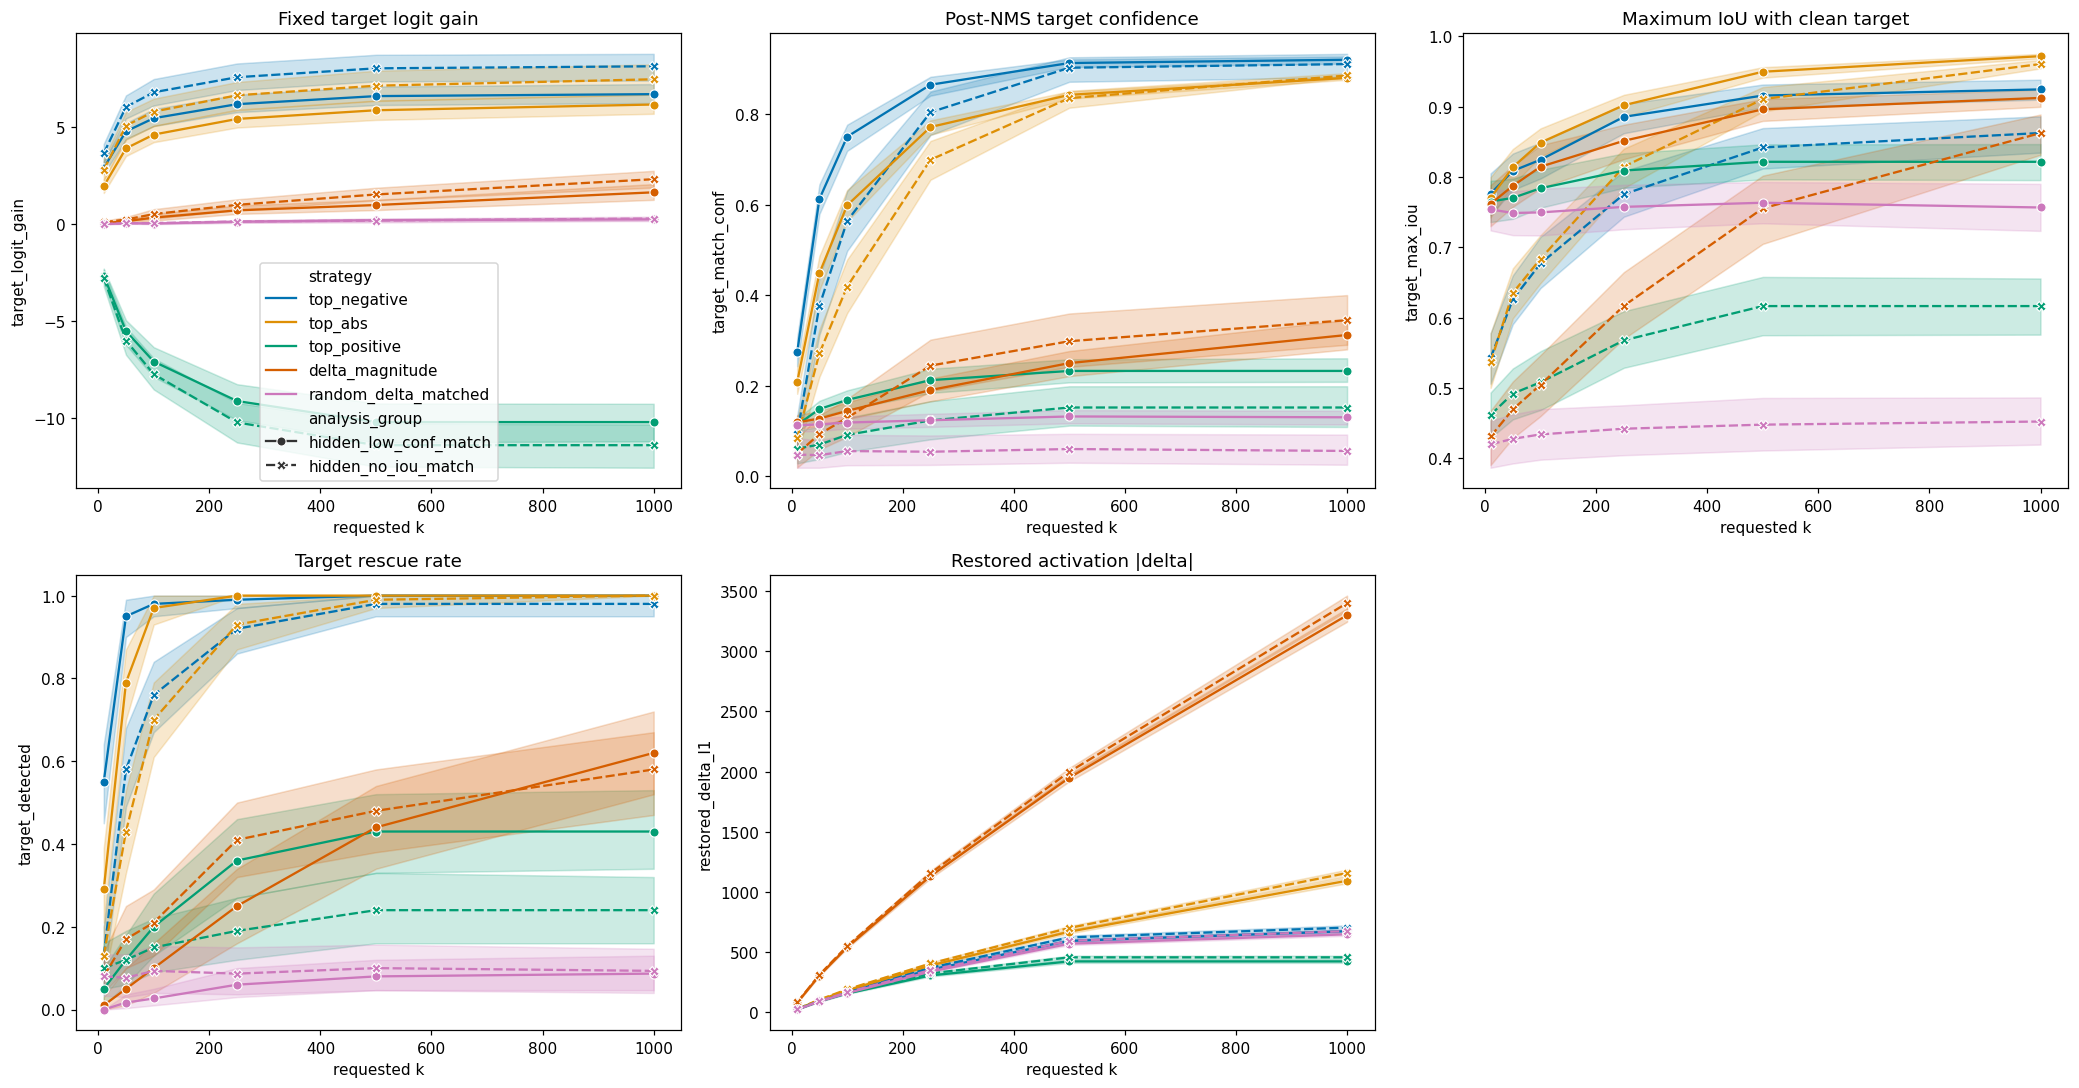

In [5]:
strategy_order = ['top_negative','top_abs','top_positive','delta_magnitude','random_delta_matched']
hidden_order = ['hidden_low_conf_match','hidden_no_iou_match']
selective_dose = repair_unit.query("k_requested > 0 and strategy in @strategy_order").copy()
zero_source = repair_unit.query("strategy == 'patched' and k_requested == 0").copy()
zero_dose = pd.concat([zero_source.assign(strategy=strategy) for strategy in strategy_order], ignore_index=True)
zero_dose['k_requested'] = 0
zero_dose['actual_k'] = 0
zero_dose['restored_delta_l1'] = 0.0
dose = pd.concat([zero_dose, selective_dose], ignore_index=True)
palette = dict(zip(strategy_order, sns.color_palette('colorblind', len(strategy_order))))
outcomes = [
    ('target_logit_gain','Fixed target logit gain'),
    ('target_match_conf','Post-NMS target confidence'),
    ('target_max_iou','Maximum IoU with clean target'),
    ('target_detected','Target rescue rate'),
    ('restored_delta_l1','Restored activation |delta|'),
]
fig, axes = plt.subplots(2, 3, figsize=(19,10))
for ax, (metric, title) in zip(axes.flat, outcomes):
    sns.lineplot(data=dose[dose.analysis_group.isin(hidden_order)], x='k_requested', y=metric, hue='strategy', style='analysis_group', hue_order=strategy_order, style_order=hidden_order, palette=palette, markers=True, dashes=True, errorbar=('ci',95), ax=ax)
    ax.set(title=title, xlabel='requested k')
    if metric != 'target_logit_gain': ax.get_legend().remove()
axes.flat[-1].axis('off'); plt.tight_layout(); plt.show()

**Что видно на графике.** Все стратегии теперь начинаются с общего фактического patched baseline при `k=0`: logit gain и восстановленная activation L1 равны нулю, а confidence/IoU/rescue показывают исходное состояние до repair. От этой точки `top_negative` даёт чёткий dose-response и восстанавливает именно выбранного target: для low-confidence rescue равен `55%` уже при `k=10`, `95%` при `50`, `98%` при `100` и `99%` при `250`; для более трудного no-IoU режима — `13%`, `58%`, `76%` и `92%`. К `k≈600` доступные negative coordinates почти исчерпаны, и rescue достигает `100%/98%`. `top_abs` приближается к этому результату, но при малых k обычно слабее signed selection.

Контроли разделяются содержательно: random почти не спасает target, `delta_magnitude` при `k=1000` возвращает в несколько раз больше activation L1 (`≈3300–3400` против `≈670–700`), но rescue остаётся лишь `62%/58%`. Значит, важен не объём восстановленного сигнала, а выбранные causal coordinates. `top_positive` делает fixed logit ещё ниже и восстанавливает target плохо, что подтверждает роль знака. Для no-IoU confidence и geometry восстанавливаются медленнее, чем для low-confidence: этот режим содержит дополнительную box/routing составляющую.

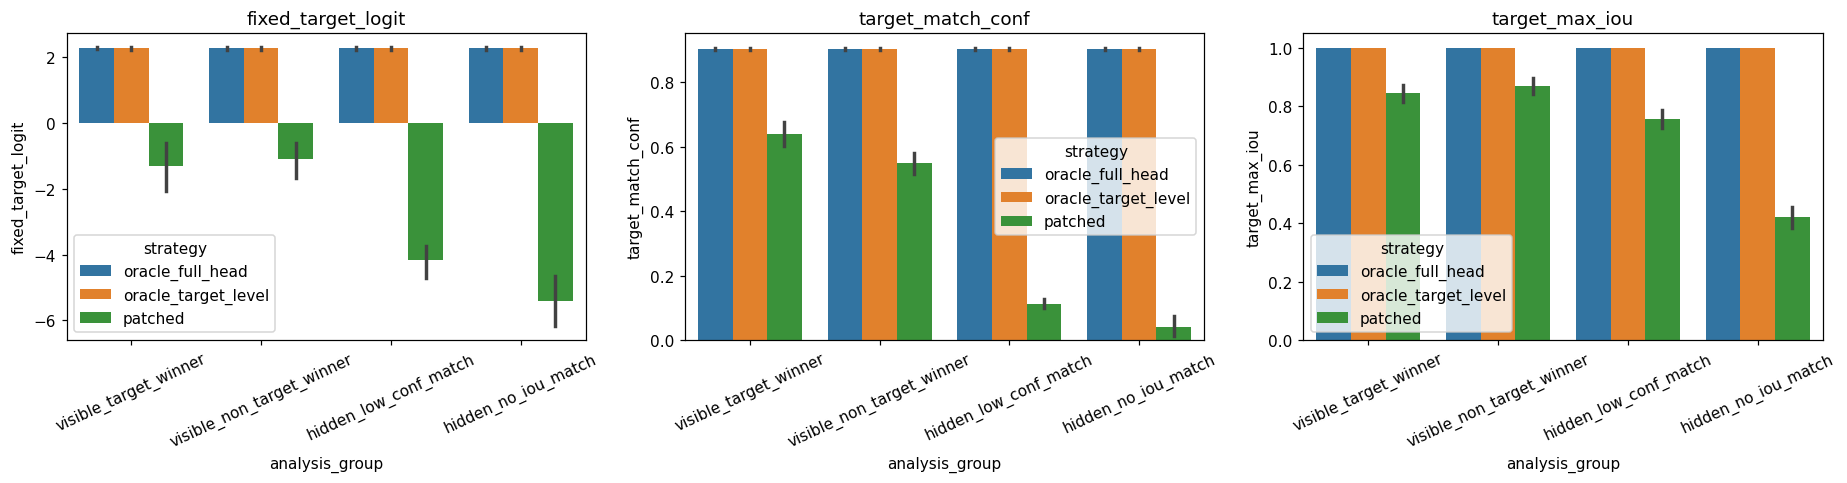

: 

In [ ]:
oracle = repair_unit[repair_unit.strategy.isin(['patched','oracle_target_level','oracle_full_head'])]
fig, axes = plt.subplots(1,3,figsize=(17,4.5))
for ax, metric in zip(axes, ['fixed_target_logit','target_match_conf','target_max_iou']):
    sns.barplot(data=oracle, x='analysis_group', y=metric, hue='strategy', order=GROUP_ORDER, errorbar=('ci',95), ax=ax)
    ax.set_title(metric); ax.tick_params(axis='x', rotation=25)
plt.tight_layout(); plt.show()

**Что видно на графике.** Полное восстановление только target feature level практически совпадает с восстановлением всего Detect-input: fixed logit возвращается примерно к `2.3`, post-NMS confidence — к `0.90`, maximum IoU — к `1.0` во всех четырёх группах. На patched baseline скрытые группы при этом имеют отрицательный logit, confidence около `0.11/0.04` и IoU около `0.75/0.42`. Следовательно, необходимое воздействие патча локализовано на уровне feature pyramid, где находился clean target; cross-level восстановление не требуется. Но oracle заменяет все координаты этого уровня, поэтому сам по себе не показывает, какая ветвь Detect head — classification или regression — несёт эффект.

## Как принимать решение

1. `top_negative` дозозависимо превосходит controls по logit и rescue confidence+IoU — signed components являются необходимыми mediators.
2. Confidence восстанавливается, IoU нет — geometry требует отдельного output/path или более раннего вмешательства.
3. `delta_magnitude`/random работают так же хорошо — attribution не выделяет специфический путь.
4. Fixed logit восстанавливается, post-NMS target нет — механизм clean cell недостаточен из-за rerouting/box decoding/NMS.